# 🎮 Deep Q-Network (DQN) Training

In this notebook, we implement a **Deep Q-Network (DQN)** from scratch.

We will:

- create environment
- build neural network
- implement replay buffer
- train agent using DQN
- evaluate performance

---

## 🧠 Goal

Train an agent to learn optimal actions using:

- Q-learning
- neural networks
- experience replay
- target network

In [10]:
import gym
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
from collections import deque

## ⚙️ Environment Setup

We use **CartPole-v1** environment:

- State: 4 values
- Actions: 2 (left, right)

Goal: Balance the pole

In [11]:
env = gym.make("CartPole-v1")

state_size = env.observation_space.shape[0]
action_size = env.action_space.n

print("State size:", state_size)
print("Action size:", action_size)

State size: 4
Action size: 2


## 🧠 DQN Model

Neural network maps:

State → Q-values for each action

In [12]:
class DQN(nn.Module):
    def __init__(self, state_size, action_size):
        super(DQN, self).__init__()
        
        self.net = nn.Sequential(
            nn.Linear(state_size, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, action_size)
        )

    def forward(self, x):
        return self.net(x)

## 📦 Replay Buffer

Stores experiences for stable training

In [13]:
class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def add(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)

        return (
            torch.FloatTensor(states),
            torch.LongTensor(actions),
            torch.FloatTensor(rewards),
            torch.FloatTensor(next_states),
            torch.FloatTensor(dones)
        )

    def size(self):
        return len(self.buffer)

## ⚙️ Hyperparameters

In [14]:
learning_rate = 0.001
gamma = 0.99

epsilon = 1.0
epsilon_decay = 0.995
epsilon_min = 0.01

batch_size = 64
buffer_size = 10000

target_update_freq = 10
episodes = 300

## 🏗️ Initialize Components

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

policy_net = DQN(state_size, action_size).to(device)
target_net = DQN(state_size, action_size).to(device)

target_net.load_state_dict(policy_net.state_dict())
target_net.eval()

optimizer = optim.Adam(policy_net.parameters(), lr=learning_rate)

buffer = ReplayBuffer(buffer_size)

## 🎯 Training Loop

In [18]:
rewards_history = []

for episode in range(episodes):
    state, _ = env.reset()
    total_reward = 0

    done = False

    while not done:
        # Convert state to tensor
        state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)

        # Epsilon-greedy action selection
        if random.random() < epsilon:
            action = env.action_space.sample()
        else:
            with torch.no_grad():
                q_values = policy_net(state_tensor)
                action = torch.argmax(q_values).item()

        # Take action
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        # Store experience
        buffer.add(state, action, reward, next_state, done)

        state = next_state
        total_reward += reward

        # Train if enough samples
        if buffer.size() >= batch_size:
            states, actions, rewards, next_states, dones = buffer.sample(batch_size)

            states = states.to(device)
            actions = actions.to(device)
            rewards = rewards.to(device)
            next_states = next_states.to(device)
            dones = dones.to(device)

            # Current Q values
            q_values = policy_net(states)
            q_values = q_values.gather(1, actions.unsqueeze(1)).squeeze(1)

            # Target Q values
            with torch.no_grad():
                next_q_values = target_net(next_states)
                max_next_q = next_q_values.max(1)[0]
                target = rewards + gamma * max_next_q * (1 - dones)

            # Loss
            loss = nn.MSELoss()(q_values, target)

            # Backpropagation
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    # Update epsilon
    epsilon = max(epsilon_min, epsilon * epsilon_decay)

    # Update target network
    if episode % target_update_freq == 0:
        target_net.load_state_dict(policy_net.state_dict())

    rewards_history.append(total_reward)

    print(f"Episode {episode+1}, Reward: {total_reward}, Epsilon: {epsilon:.3f}")

Episode 1, Reward: 16.0, Epsilon: 0.995
Episode 2, Reward: 13.0, Epsilon: 0.990
Episode 3, Reward: 16.0, Epsilon: 0.985
Episode 4, Reward: 30.0, Epsilon: 0.980
Episode 5, Reward: 10.0, Epsilon: 0.975
Episode 6, Reward: 17.0, Epsilon: 0.970
Episode 7, Reward: 27.0, Epsilon: 0.966
Episode 8, Reward: 12.0, Epsilon: 0.961
Episode 9, Reward: 19.0, Epsilon: 0.956
Episode 10, Reward: 13.0, Epsilon: 0.951
Episode 11, Reward: 24.0, Epsilon: 0.946
Episode 12, Reward: 23.0, Epsilon: 0.942
Episode 13, Reward: 9.0, Epsilon: 0.937
Episode 14, Reward: 16.0, Epsilon: 0.932
Episode 15, Reward: 39.0, Epsilon: 0.928
Episode 16, Reward: 11.0, Epsilon: 0.923
Episode 17, Reward: 20.0, Epsilon: 0.918
Episode 18, Reward: 14.0, Epsilon: 0.914
Episode 19, Reward: 14.0, Epsilon: 0.909
Episode 20, Reward: 21.0, Epsilon: 0.905
Episode 21, Reward: 20.0, Epsilon: 0.900
Episode 22, Reward: 21.0, Epsilon: 0.896
Episode 23, Reward: 11.0, Epsilon: 0.891
Episode 24, Reward: 27.0, Epsilon: 0.887
Episode 25, Reward: 15.0, 

## 📊 Training Result

Observe reward improvement over episodes.

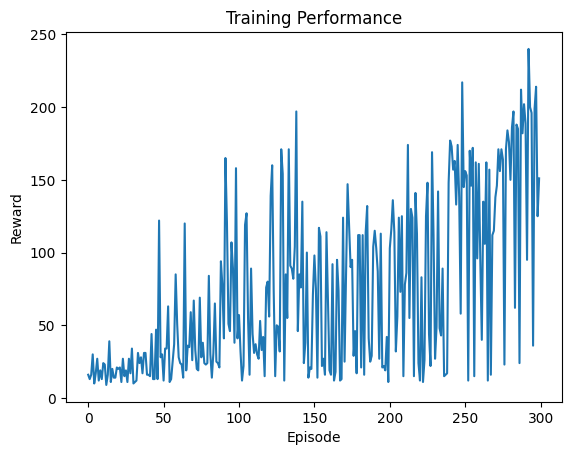

In [19]:
import matplotlib.pyplot as plt

plt.plot(rewards_history)
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Training Performance")
plt.show()

## 🧠 Final Summary

- DQN replaces Q-table with neural network
- Replay buffer stabilizes training
- Target network prevents instability
- Epsilon decay balances exploration

👉 Agent improves over time by learning from experience